In [3]:
import numpy as np
import pandas as pd
from pathlib import Path
import json
import yaml
import shutil
from collections import defaultdict
import random
import ast
import matplotlib.pyplot as plt

In [4]:
# ============================================
# НАСТРОЙКИ
# ============================================

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

DATA_PATH = Path("data/256_yolo/defect_patches")
OUTPUT_PATH = Path("data/256_yolo/balanced_defect_patches")
IMAGES_PATH = DATA_PATH / "images" / "train"
LABELS_PATH = DATA_PATH / "labels" / "train"

print("="*80)
print("ОТБОР СБАЛАНСИРОВАННЫХ ПАТЧЕЙ С ДЕФЕКТАМИ")
print("="*80)

ОТБОР СБАЛАНСИРОВАННЫХ ПАТЧЕЙ С ДЕФЕКТАМИ


In [5]:
# ============================================
# 1. ЗАГРУЗКА ДАННЫХ
# ============================================

print(f"\n📊 ЗАГРУЗКА ДАННЫХ:")

metadata = pd.read_csv(DATA_PATH / "patches_metadata.csv")
with open(DATA_PATH / "annotations.json", 'r', encoding='utf-8') as f:
    annotations = json.load(f)
with open(DATA_PATH / "dataset.yaml", 'r', encoding='utf-8') as f:
    dataset_config = yaml.safe_load(f)

class_names = dataset_config.get('names', [])

# Словари реальных файлов
real_images = {img.stem: img.name for img in IMAGES_PATH.glob("*.png")}
real_images.update({img.stem: img.name for img in IMAGES_PATH.glob("*.jpg")})
real_labels = {lbl.stem: lbl.name for lbl in LABELS_PATH.glob("*.txt")}

print(f"  ✅ Загружено: {len(metadata)} патчей, {len(class_names)} классов")


📊 ЗАГРУЗКА ДАННЫХ:
  ✅ Загружено: 15987 патчей, 4 классов


In [6]:
# ============================================
# 2. АНАЛИЗ ПАТЧЕЙ ПО КЛАССАМ
# ============================================

patches_by_class = defaultdict(list)
ann_dict = {ann['saved_as']: ann for ann in annotations}

for idx, row in metadata.iterrows():
    patch_name = row['saved_as']
    base_name = patch_name.replace('.png', '').replace('.jpg', '')
    
    if base_name not in real_images:
        continue
    
    ann = ann_dict.get(patch_name, {})
    classes_in_patch = set()
    
    if 'classes' in ann:
        classes_in_patch = set(ann['classes'])
    elif 'classes_present' in row:
        val = row['classes_present']
        if isinstance(val, str):
            try:
                classes_list = ast.literal_eval(val)
            except:
                clean = val.strip('[]')
                classes_list = [int(x.strip()) for x in clean.split(',') if x.strip()]
        else:
            classes_list = val
        classes_in_patch = set(classes_list if isinstance(classes_list, list) else [classes_list])
    
    # Нормализация индексов (1-4 -> 0-3)
    for c in classes_in_patch:
        class_id = c - 1 if c >= 1 and c <= 4 else c
        patches_by_class[class_id].append(patch_name)

actual_class_ids = sorted(patches_by_class.keys())

print(f"\n📊 РАСПРЕДЕЛЕНИЕ ПО КЛАССАМ:")
for class_id in actual_class_ids:
    name = class_names[class_id]
    count = len(patches_by_class[class_id])
    print(f"  {name}: {count} патчей")

# Миноритарный класс
min_class = min(actual_class_ids, key=lambda x: len(patches_by_class[x]))
min_count = len(patches_by_class[min_class])
min_name = class_names[min_class]

print(f"\n🎯 МИНОРИТАРНЫЙ КЛАСС: {min_name} ({min_count} патчей)")


📊 РАСПРЕДЕЛЕНИЕ ПО КЛАССАМ:
  defect_type_1: 1568 патчей
  defect_type_2: 263 патчей
  defect_type_3: 12402 патчей
  defect_type_4: 2039 патчей

🎯 МИНОРИТАРНЫЙ КЛАСС: defect_type_2 (263 патчей)


In [7]:
# ============================================
# 3. ОТБОР ПАТЧЕЙ
# ============================================

print(f"\n📦 ОТБОР ПАТЧЕЙ:")

selected = set()
selected_by_class = {}

# Миноритарный класс - все
selected.update(patches_by_class[min_class])
selected_by_class[min_class] = sorted(patches_by_class[min_class])
print(f"  {min_name}: {len(selected_by_class[min_class])} патчей")

# Остальные - в 2 раза больше
for class_id in actual_class_ids:
    if class_id == min_class:
        continue
    
    available = sorted(patches_by_class[class_id])
    target = min(min_count * 2, len(available))
    
    random.shuffle(available)
    selected_patches = available[:target]
    
    selected.update(selected_patches)
    selected_by_class[class_id] = selected_patches
    
    name = class_names[class_id]
    print(f"  {name}: {len(selected_patches)} патчей")

print(f"\n✅ ВСЕГО ОТОБРАНО: {len(selected)} патчей")


📦 ОТБОР ПАТЧЕЙ:
  defect_type_2: 263 патчей
  defect_type_1: 526 патчей
  defect_type_3: 526 патчей
  defect_type_4: 526 патчей

✅ ВСЕГО ОТОБРАНО: 1826 патчей


In [8]:
# ============================================
# 4. КОПИРОВАНИЕ ФАЙЛОВ
# ============================================

print(f"\n📁 КОПИРОВАНИЕ ФАЙЛОВ:")

if OUTPUT_PATH.exists():
    shutil.rmtree(OUTPUT_PATH)
OUTPUT_PATH.mkdir(parents=True)
(OUTPUT_PATH / "images").mkdir()
(OUTPUT_PATH / "labels").mkdir()

new_metadata = []
new_annotations = []
copied_img = 0
copied_lbl = 0

for idx, row in metadata.iterrows():
    patch_name = row['saved_as']
    
    if patch_name in selected:
        base_name = patch_name.replace('.png', '').replace('.jpg', '')
        
        real_img = real_images.get(base_name)
        real_lbl = real_labels.get(base_name)
        
        if real_img:
            shutil.copy2(IMAGES_PATH / real_img, OUTPUT_PATH / "images" / real_img)
            copied_img += 1
            row_copy = row.copy()
            row_copy['saved_as'] = real_img
            new_metadata.append(row_copy)
        
        if real_lbl:
            shutil.copy2(LABELS_PATH / real_lbl, OUTPUT_PATH / "labels" / real_lbl)
            copied_lbl += 1
        
        ann = ann_dict.get(patch_name, {})
        if ann:
            ann_copy = ann.copy()
            ann_copy['id'] = len(new_annotations)
            if real_img:
                ann_copy['saved_as'] = real_img
            new_annotations.append(ann_copy)

print(f"  ✅ Изображений: {copied_img}, Лейблов: {copied_lbl}")


📁 КОПИРОВАНИЕ ФАЙЛОВ:
  ✅ Изображений: 1826, Лейблов: 1826


In [9]:
# ============================================
# 5. СОХРАНЕНИЕ МЕТАДАННЫХ
# ============================================

pd.DataFrame(new_metadata).to_csv(OUTPUT_PATH / "patches_metadata.csv", index=False)
print(f"  ✅ patches_metadata.csv")

with open(OUTPUT_PATH / "annotations.json", 'w', encoding='utf-8') as f:
    json.dump(new_annotations, f, indent=2, ensure_ascii=False)
print(f"  ✅ annotations.json")

dataset_config['path'] = str(OUTPUT_PATH.absolute())
dataset_config['train'] = 'images'
dataset_config['val'] = 'images'

with open(OUTPUT_PATH / "dataset.yaml", 'w', encoding='utf-8') as f:
    yaml.dump(dataset_config, f, default_flow_style=False, allow_unicode=True)
print(f"  ✅ dataset.yaml")

  ✅ patches_metadata.csv
  ✅ annotations.json
  ✅ dataset.yaml


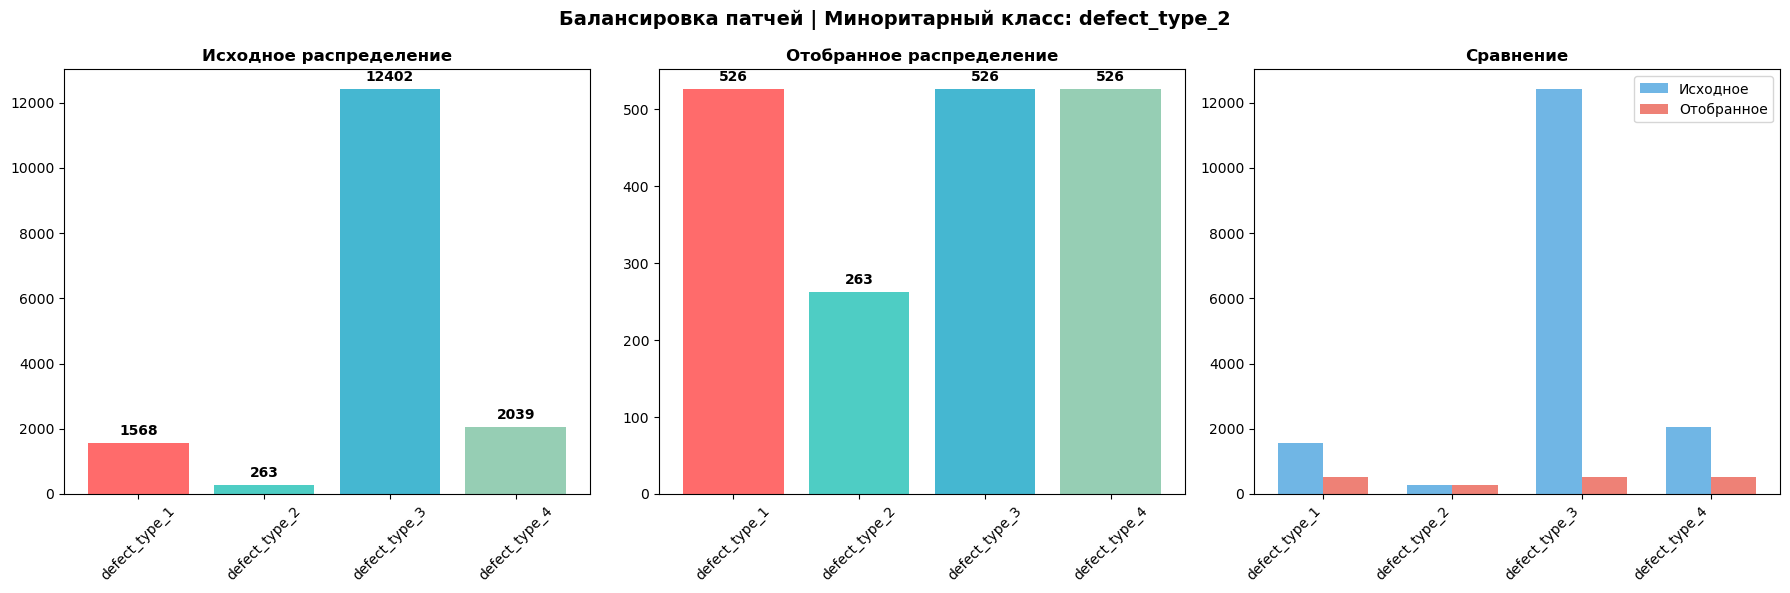

  ✅ selection_analysis.png


In [10]:
# ============================================
# 6. ВИЗУАЛИЗАЦИЯ
# ============================================

all_ids = list(range(len(class_names)))
orig_counts = [len(patches_by_class.get(i, [])) for i in all_ids]
sel_counts = [len(selected_by_class.get(i, [])) for i in all_ids]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Исходное
bars = axes[0].bar(class_names, orig_counts, color=colors)
axes[0].set_title('Исходное распределение', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
for b, c in zip(bars, orig_counts):
    if c > 0:
        axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + max(orig_counts)*0.02, 
                     str(c), ha='center', fontweight='bold')

# Отобранное
bars = axes[1].bar(class_names, sel_counts, color=colors)
axes[1].set_title('Отобранное распределение', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
for b, c in zip(bars, sel_counts):
    if c > 0:
        axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + max(sel_counts)*0.02, 
                     str(c), ha='center', fontweight='bold')

# Сравнение
x = np.arange(len(class_names))
width = 0.35
axes[2].bar(x - width/2, orig_counts, width, label='Исходное', color='#3498db', alpha=0.7)
axes[2].bar(x + width/2, sel_counts, width, label='Отобранное', color='#e74c3c', alpha=0.7)
axes[2].set_title('Сравнение', fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(class_names, rotation=45, ha='right')
axes[2].legend()

plt.suptitle(f'Балансировка патчей | Миноритарный класс: {min_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'selection_analysis.png', dpi=150)
plt.show()

print(f"  ✅ selection_analysis.png")

In [11]:
print("\n" + "="*80)
print("ГОТОВО!")
print("="*80)
print(f"\n✅ Отобрано: {len(selected)} патчей")
print(f"📁 {OUTPUT_PATH}")
print(f"   ├── images/ ({copied_img} файлов)")
print(f"   ├── labels/ ({copied_lbl} файлов)")
print(f"   ├── patches_metadata.csv")
print(f"   ├── annotations.json")
print(f"   ├── dataset.yaml")
print(f"   └── selection_analysis.png")


ГОТОВО!

✅ Отобрано: 1826 патчей
📁 data/256_yolo/balanced_defect_patches
   ├── images/ (1826 файлов)
   ├── labels/ (1826 файлов)
   ├── patches_metadata.csv
   ├── annotations.json
   ├── dataset.yaml
   └── selection_analysis.png


ОТБОР СБАЛАНСИРОВАННЫХ ПАТЧЕЙ С РАЗБИЕНИЕМ 70/15/15
✅ Загружено: 15987 патчей, 4 классов

📊 РАСПРЕДЕЛЕНИЕ ПО КЛАССАМ:
  defect_type_1: 1568 патчей
  defect_type_2: 263 патчей
  defect_type_3: 12402 патчей
  defect_type_4: 2039 патчей

🎯 МИНОРИТАРНЫЙ КЛАСС: defect_type_2 (263 патчей)

📦 ОТБОР И РАЗБИЕНИЕ:
  defect_type_1: 526 патчей (train:368, val:78, test:80)
  defect_type_2: 263 патчей (train:184, val:39, test:40)
  defect_type_3: 526 патчей (train:368, val:78, test:80)
  defect_type_4: 526 патчей (train:368, val:78, test:80)

✅ ВСЕГО: train=1288, val=273, test=280

📁 КОПИРОВАНИЕ:
  Train: 1288 img, 1288 lbl
  Val:   273 img, 273 lbl
  Test:  280 img, 280 lbl


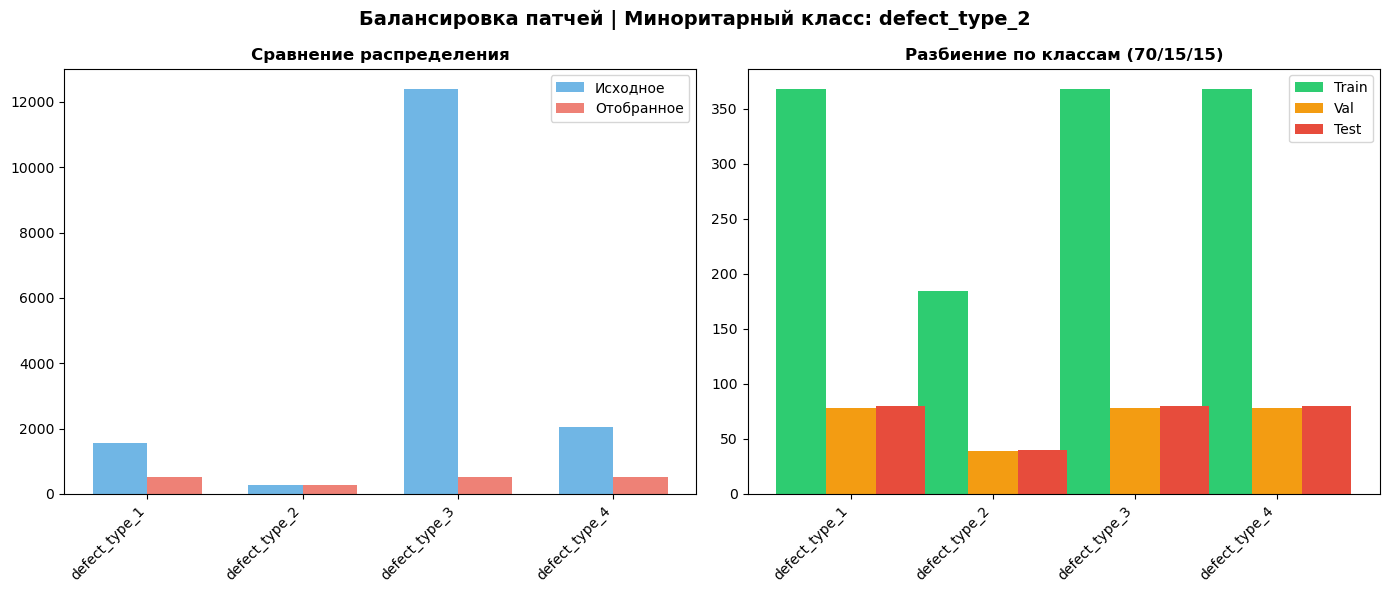


ГОТОВО!

✅ data/256_yolo/balanced_defect_patches
   ├── train/ (img:1288, lbl:1288)
   ├── val/   (img:273, lbl:273)
   ├── test/  (img:280, lbl:280)
   └── *.csv, *.json, *.yaml, *.png


In [12]:
import numpy as np
import pandas as pd
from pathlib import Path
import json
import yaml
import shutil
from collections import defaultdict
import random
import ast
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ============================================
# НАСТРОЙКИ
# ============================================
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

DATA_PATH = Path("data/256_yolo/defect_patches")
OUTPUT_PATH = Path("data/256_yolo/balanced_defect_patches")
IMAGES_PATH = DATA_PATH / "images" / "train"
LABELS_PATH = DATA_PATH / "labels" / "train"
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.70, 0.15, 0.15

print("="*80)
print("ОТБОР СБАЛАНСИРОВАННЫХ ПАТЧЕЙ С РАЗБИЕНИЕМ 70/15/15")
print("="*80)

# ============================================
# 1. ЗАГРУЗКА ДАННЫХ
# ============================================
metadata = pd.read_csv(DATA_PATH / "patches_metadata.csv")
with open(DATA_PATH / "annotations.json", 'r', encoding='utf-8') as f:
    annotations = json.load(f)
with open(DATA_PATH / "dataset.yaml", 'r', encoding='utf-8') as f:
    dataset_config = yaml.safe_load(f)

class_names = dataset_config.get('names', [])
real_images = {img.stem: img.name for img in IMAGES_PATH.glob("*.png")}
real_images.update({img.stem: img.name for img in IMAGES_PATH.glob("*.jpg")})
real_labels = {lbl.stem: lbl.name for lbl in LABELS_PATH.glob("*.txt")}
ann_dict = {ann['saved_as']: ann for ann in annotations}

print(f"✅ Загружено: {len(metadata)} патчей, {len(class_names)} классов")

# ============================================
# 2. АНАЛИЗ ПАТЧЕЙ ПО КЛАССАМ
# ============================================
patches_by_class = defaultdict(list)

for idx, row in metadata.iterrows():
    patch_name = row['saved_as']
    base_name = patch_name.replace('.png', '').replace('.jpg', '')
    if base_name not in real_images:
        continue
    
    ann = ann_dict.get(patch_name, {})
    classes_in_patch = set()
    if 'classes' in ann:
        classes_in_patch = set(ann['classes'])
    elif 'classes_present' in row:
        val = row['classes_present']
        if isinstance(val, str):
            try:
                classes_list = ast.literal_eval(val)
            except:
                classes_list = [int(x.strip()) for x in val.strip('[]').split(',') if x.strip()]
        else:
            classes_list = val
        classes_in_patch = set(classes_list if isinstance(classes_list, list) else [classes_list])
    
    for c in classes_in_patch:
        class_id = c - 1 if c >= 1 and c <= 4 else c
        patches_by_class[class_id].append((patch_name, base_name, row, ann))

actual_class_ids = sorted(patches_by_class.keys())
print(f"\n📊 РАСПРЕДЕЛЕНИЕ ПО КЛАССАМ:")
for cid in actual_class_ids:
    print(f"  {class_names[cid]}: {len(patches_by_class[cid])} патчей")

min_class = min(actual_class_ids, key=lambda x: len(patches_by_class[x]))
min_count = len(patches_by_class[min_class])
min_name = class_names[min_class]
print(f"\n🎯 МИНОРИТАРНЫЙ КЛАСС: {min_name} ({min_count} патчей)")

# ============================================
# 3. ОТБОР ПАТЧЕЙ И РАЗБИЕНИЕ НА TRAIN/VAL/TEST
# ============================================
print(f"\n📦 ОТБОР И РАЗБИЕНИЕ:")

selected_by_split = {'train': [], 'val': [], 'test': []}
selected_by_class = defaultdict(lambda: {'train': [], 'val': [], 'test': []})
final_counts = defaultdict(int)

for class_id in actual_class_ids:
    patches = patches_by_class[class_id]
    random.shuffle(patches)
    
    if class_id == min_class:
        target = min_count
    else:
        target = min(min_count * 2, len(patches))
    
    selected_patches = patches[:target]
    random.shuffle(selected_patches)
    
    # Разбиение 70/15/15
    train_end = int(target * TRAIN_RATIO)
    val_end = train_end + int(target * VAL_RATIO)
    
    splits = {
        'train': selected_patches[:train_end],
        'val': selected_patches[train_end:val_end],
        'test': selected_patches[val_end:]
    }
    
    for split_name, split_patches in splits.items():
        selected_by_split[split_name].extend([p[0] for p in split_patches])
        selected_by_class[class_id][split_name] = [p[0] for p in split_patches]
        final_counts[class_id] += len(split_patches)
    
    name = class_names[class_id]
    print(f"  {name}: {final_counts[class_id]} патчей (train:{len(splits['train'])}, val:{len(splits['val'])}, test:{len(splits['test'])})")

print(f"\n✅ ВСЕГО: train={len(selected_by_split['train'])}, val={len(selected_by_split['val'])}, test={len(selected_by_split['test'])}")

# ============================================
# 4. КОПИРОВАНИЕ ФАЙЛОВ
# ============================================
print(f"\n📁 КОПИРОВАНИЕ:")

if OUTPUT_PATH.exists():
    shutil.rmtree(OUTPUT_PATH)

new_metadata = {'train': [], 'val': [], 'test': []}
new_annotations = {'train': [], 'val': [], 'test': []}
copied = {'train': {'img': 0, 'lbl': 0}, 'val': {'img': 0, 'lbl': 0}, 'test': {'img': 0, 'lbl': 0}}

for split_name in ['train', 'val', 'test']:
    (OUTPUT_PATH / split_name / "images").mkdir(parents=True)
    (OUTPUT_PATH / split_name / "labels").mkdir(parents=True)

for split_name in ['train', 'val', 'test']:
    for patch_name in selected_by_split[split_name]:
        base_name = patch_name.replace('.png', '').replace('.jpg', '')
        real_img = real_images.get(base_name)
        real_lbl = real_labels.get(base_name)
        
        if real_img:
            shutil.copy2(IMAGES_PATH / real_img, OUTPUT_PATH / split_name / "images" / real_img)
            copied[split_name]['img'] += 1
            
            # Найти соответствующую строку в metadata
            for _, row in metadata.iterrows():
                if row['saved_as'] == patch_name:
                    row_copy = row.copy()
                    row_copy['saved_as'] = real_img
                    row_copy['split'] = split_name
                    new_metadata[split_name].append(row_copy)
                    break
        
        if real_lbl:
            shutil.copy2(LABELS_PATH / real_lbl, OUTPUT_PATH / split_name / "labels" / real_lbl)
            copied[split_name]['lbl'] += 1
        
        ann = ann_dict.get(patch_name, {})
        if ann:
            ann_copy = ann.copy()
            ann_copy['id'] = len(new_annotations[split_name])
            ann_copy['split'] = split_name
            if real_img:
                ann_copy['saved_as'] = real_img
            new_annotations[split_name].append(ann_copy)

print(f"  Train: {copied['train']['img']} img, {copied['train']['lbl']} lbl")
print(f"  Val:   {copied['val']['img']} img, {copied['val']['lbl']} lbl")
print(f"  Test:  {copied['test']['img']} img, {copied['test']['lbl']} lbl")

# ============================================
# 5. СОХРАНЕНИЕ МЕТАДАННЫХ
# ============================================
all_metadata = pd.concat([pd.DataFrame(new_metadata[s]) for s in ['train', 'val', 'test']])
all_metadata.to_csv(OUTPUT_PATH / "patches_metadata.csv", index=False)

all_annotations = new_annotations['train'] + new_annotations['val'] + new_annotations['test']
with open(OUTPUT_PATH / "annotations.json", 'w', encoding='utf-8') as f:
    json.dump(all_annotations, f, indent=2, ensure_ascii=False)

dataset_config['path'] = str(OUTPUT_PATH.absolute())
dataset_config['train'] = 'train/images'
dataset_config['val'] = 'val/images'
dataset_config['test'] = 'test/images'

with open(OUTPUT_PATH / "dataset.yaml", 'w', encoding='utf-8') as f:
    yaml.dump(dataset_config, f, default_flow_style=False, allow_unicode=True)

# ============================================
# 6. ВИЗУАЛИЗАЦИЯ
# ============================================
all_ids = list(range(len(class_names)))
orig_counts = [len(patches_by_class.get(i, [])) for i in all_ids]
sel_counts = [final_counts.get(i, 0) for i in all_ids]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

x = np.arange(len(class_names))
width = 0.35
axes[0].bar(x - width/2, orig_counts, width, label='Исходное', color='#3498db', alpha=0.7)
axes[0].bar(x + width/2, sel_counts, width, label='Отобранное', color='#e74c3c', alpha=0.7)
axes[0].set_title('Сравнение распределения', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(class_names, rotation=45, ha='right')
axes[0].legend()

# Распределение по сплитам
train_counts = [len(selected_by_class.get(i, {}).get('train', [])) for i in all_ids]
val_counts = [len(selected_by_class.get(i, {}).get('val', [])) for i in all_ids]
test_counts = [len(selected_by_class.get(i, {}).get('test', [])) for i in all_ids]

axes[1].bar(x - width, train_counts, width, label='Train', color='#2ecc71')
axes[1].bar(x, val_counts, width, label='Val', color='#f39c12')
axes[1].bar(x + width, test_counts, width, label='Test', color='#e74c3c')
axes[1].set_title('Разбиение по классам (70/15/15)', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(class_names, rotation=45, ha='right')
axes[1].legend()

plt.suptitle(f'Балансировка патчей | Миноритарный класс: {min_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'selection_analysis.png', dpi=150)
plt.show()

print("\n" + "="*80)
print("ГОТОВО!")
print("="*80)
print(f"\n✅ {OUTPUT_PATH}")
print(f"   ├── train/ (img:{copied['train']['img']}, lbl:{copied['train']['lbl']})")
print(f"   ├── val/   (img:{copied['val']['img']}, lbl:{copied['val']['lbl']})")
print(f"   ├── test/  (img:{copied['test']['img']}, lbl:{copied['test']['lbl']})")
print(f"   └── *.csv, *.json, *.yaml, *.png")